<h2>BodyFat Prediction Using Custom Gradient Descent Multiple Linear Regression On Bodyparts Measurements</h2>

In [154]:
import pandas as pd 
import matplotlib.pyplot as plt 
import math
from pathlib import Path

<h3>Lets get our dataset</h3>

In [155]:
dataset_path = Path("../dataset/bodyfat.csv")
insurance_df = pd.read_csv(dataset_path)
insurance_df.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


<h3>Metadata</h3>
The variables listed above, from left to right, are:
<ol>
    <li>Density determined from underwater weighing</li>
    <li>Percent body fat from Siri's (1956) equation  <b> -> Our target variable</b></li> 
    <li>Age (years)</li>
    <li>Weight (lbs)</li>
    <li>Height (inches)</li>
    <li>Neck circumference (cm)</li>
    <li>Chest circumference (cm)</li>
    <li>Abdomen 2 circumference (cm)</li>
    <li>Hip circumference (cm)</li>
    <li>Thigh circumference (cm)</li>
    <li>Knee circumference (cm)</li>
    <li>Ankle circumference (cm)</li>
    <li>Biceps (extended) circumference (cm)</li>
    <li>Forearm circumference (cm)</li>
    <li>Wrist circumference (cm)</li>
</ol>


<h3>Initial Data Visualization Analysis</h3>

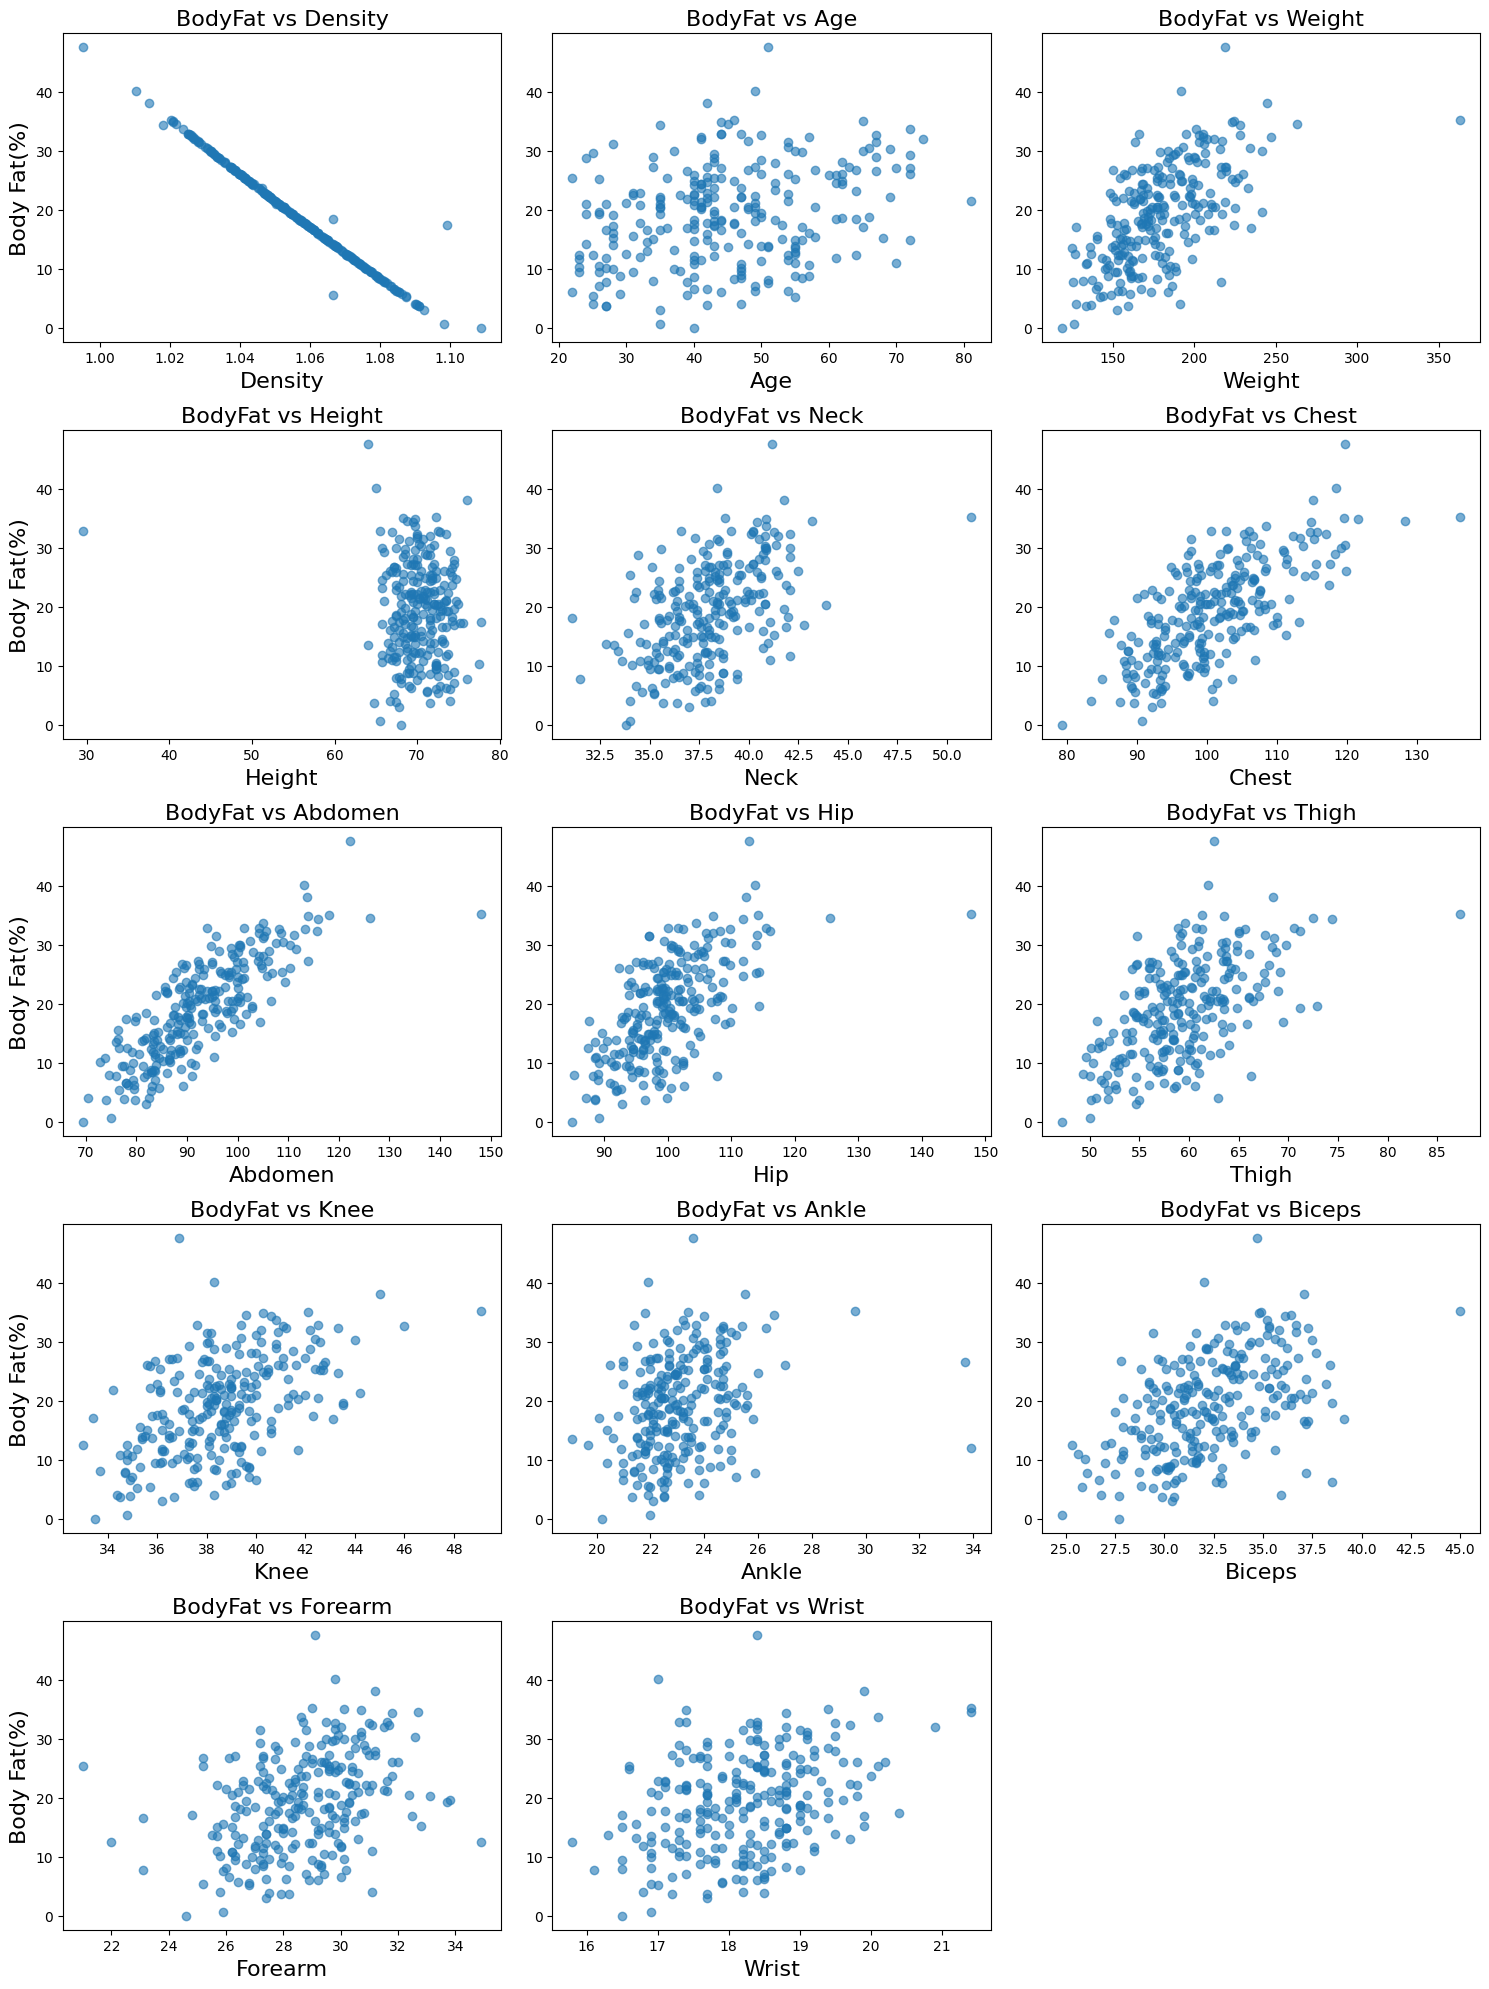

In [156]:
x_train = insurance_df.drop(columns = "BodyFat", inplace= False)
y_train = insurance_df["BodyFat"]
m, n = x_train.shape
headers = x_train.columns.to_list()
n_cols = 3
m_rows = math.ceil(n / n_cols)
fig, ax = plt.subplots(m_rows, n_cols, figsize = (n_cols * 5, m_rows * 4))
ax = ax.flatten()
for i in range(n):
    ax[i].scatter(x_train[headers[i]], y_train, alpha = 0.6)
    ax[i].set_xlabel(headers[i], fontsize = 16)
    ax[i].set_title(f"BodyFat vs {headers[i]}", fontsize = 16)
    if (i % 3 == 0): 
        ax[i].set_ylabel("Body Fat(%)", fontsize = 16)
for j in range(n, len(ax)):
    fig.delaxes(ax[j])
plt.tight_layout()
plt.show()

We can see that almost all features (except Density) have positive linear relationship compared to bodyfat. The Height vs Bodyfat even though quite dense together because there seem to be an outlier person whose height is around 30 inches (76,2cm) which stretch the graph out. This is turned out to be a mistake typo from the scientists who conducted this dataset, so i will remove the error data entry. <br>
<b>However</b> the bodyfat vs density graph form an almost perfect straight line, this is because the bodyfat in this dataset is directly computed using density. This means that if we try to run gradient descent on this dataset, then it would completely ignore the other features and would make their weights a very small number close to 0 and make the weight of density a very large one. Thus because we would want to predict bodyfat using the other measurements (as not everyone has a hundred thousand of dollar equipment to measure their density), therefore we would want to drop the density column.

In [157]:
insurance_df = insurance_df[insurance_df["Height"] > 40]
x_train = insurance_df.drop(columns = "BodyFat", inplace= False)
y_train = insurance_df["BodyFat"]
x_train.drop(columns= "Density", inplace = True)
headers = x_train.columns.to_list()

<h3>Feature Scaling</h3>

Next lets handle the data from other features as we can see the data range varies a lot from each features. We will use <b>Z-score normalization</b> for this dataset

In [158]:
from sklearn import preprocessing 

scaler = preprocessing.StandardScaler()
scaler.fit(x_train)
x_train_np = scaler.transform(x_train)

<h3>Custom Gradient Descent for Multiple Linear Regression</h3>

Initial data visualization analysis and feature scaling is done, now lets run our custom gradient descent using fully vectorization <br>
(If you haven't seen my custom batch gradient descent implementation, please take a look at the file src/bgd_regressor.py)

In [159]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join("..")))

In [160]:
from src.bgd_regressor import BGDRegression #get our custom gradient descent class
import numpy as np

bgd_regress = BGDRegression()
alpha = 0.03
num_iteration = 10000
m, n = x_train_np.shape
w = np.zeros((n,))
b = 0.0
w, b, J_hist, w_b_hist = bgd_regress.run_bgd_regressor(x_train_np, y_train, w, b, alpha, num_iteration) 

iteration 0: cost = 199.9653
iteration 1000: cost = 8.8980
iteration 2000: cost = 8.8001
iteration 3000: cost = 8.7903
iteration 4000: cost = 8.7879
iteration 5000: cost = 8.7871
iteration 6000: cost = 8.7869
iteration 7000: cost = 8.7868
iteration 8000: cost = 8.7867
iteration 9000: cost = 8.7867


As we can see the gradient hasn't move anywhere since iteration 8000, that is because the bgd_regressor has found the minimum for J(w,b). The gradient descent has reached close to the minimum in just iteration 1000, this is thanks to feature scaling that our batch gradient descent ran very fast.

In [161]:
#value of parameters w and b at minimum point of cost function J(w,b) = 8.7867
for i in range(n):
    print(f"weight of {headers[i]}: w{i} = {w[i]:.4f}")
print(f"bias b = {b:.4f}")

weight of Age: w0 = 0.7834
weight of Weight: w1 = -2.7350
weight of Height: w2 = -0.1182
weight of Neck: w3 = -1.1283
weight of Chest: w4 = -0.1641
weight of Abdomen: w5 = 10.3157
weight of Hip: w6 = -1.4603
weight of Thigh: w7 = 1.2493
weight of Knee: w8 = 0.0152
weight of Ankle: w9 = 0.3001
weight of Biceps: w10 = 0.5582
weight of Forearm: w11 = 0.9115
weight of Wrist: w12 = -1.5092
bias b = 19.0960


Looking at the result we can see that the weight for belly size (w = 10.3157) is massive compare to other features. This suggest that <b>abdomen size</b> is the <b>biggest predictor</b> of body fat percentage as each cm of Abdomen size multiply with the weight of 10 fold. Thigh (w = 1.2493) and forearm size (w = 0.9115) as well as age (w = 0.7834) does have some impact on bodyfat percentage compare to other features. What is interesting about the weight of <b>weight size</b> is that it is <b>negative</b>. This seem counter intuitive at first because larger weight should suggest that that person has more chance to have a higher body fat percentage. But the weight in multiple linear regression take all features as constant, and look at a single feature to figure its weight. A person with the same body part sizes, height, age but has a different weight. Where does that different weight comes from if everything else is the same? The answer is it comes from muscle. For example two person with the same chest size, say 30 cm. That two person has the same body parts size, same age, same height, but their weight is different. There can be only a explaination, muscle. As a cm of muscle weigh more than fat, and higher muscle suggest that the person has a the lower chance of carrying more bodyfat. The model discover this and assign negative weight (w = -2.7350) to that feature. 

<h3>Convergence Graph</h3>

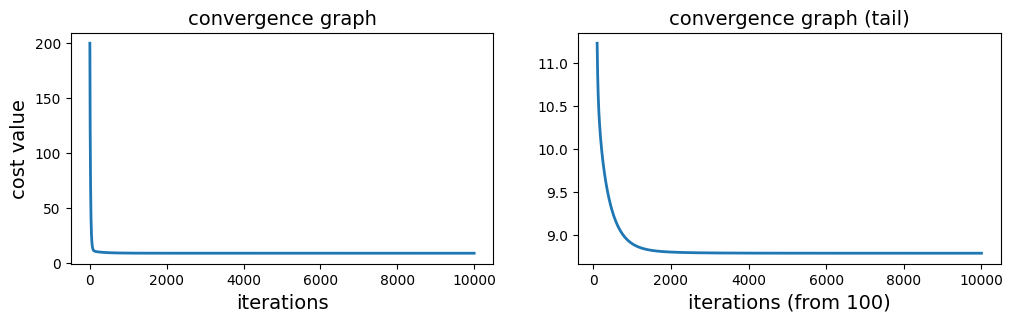

In [162]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12,3))
ax1.plot(np.arange(len(J_hist)), J_hist, linewidth = 2.0)
ax1.set_xlabel("iterations", fontsize = 14)
ax1.set_ylabel("cost value", fontsize = 14)
ax1.set_title("convergence graph", fontsize = 14)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:], linewidth = 2.0)
ax2.set_xlabel("iterations (from 100)", fontsize = 14)
ax2.set_title("convergence graph (tail)", fontsize = 14)
plt.show()

In [163]:
m, n = x_train.shape
prediction = np.dot(x_train_np, w) + b

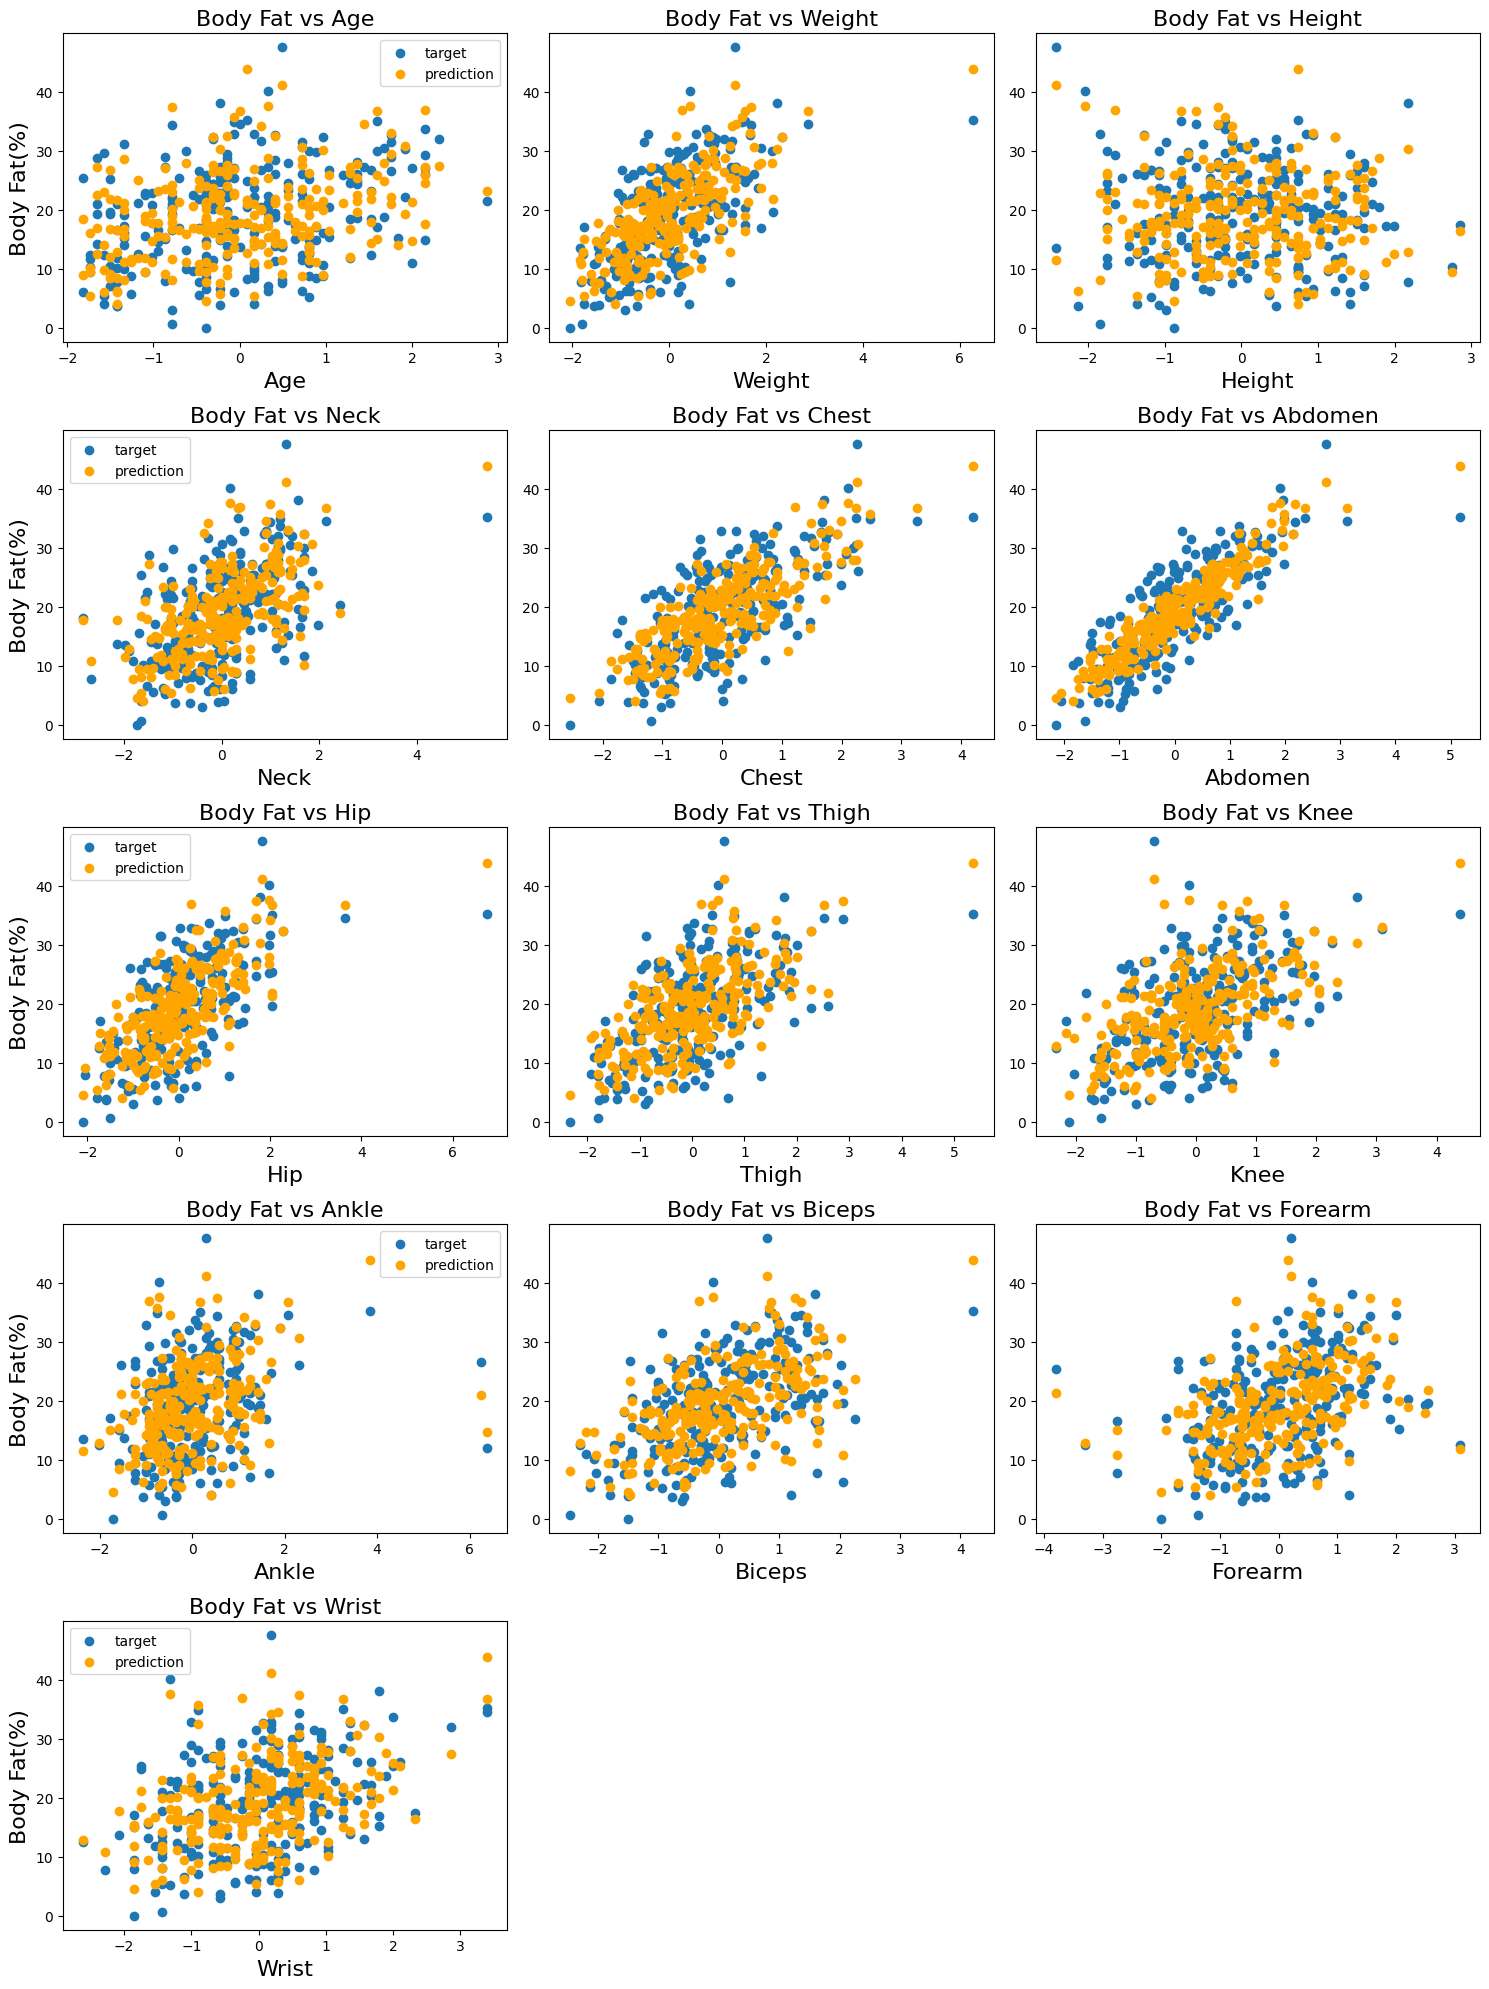

In [164]:
n_cols = 3
m_rows = math.ceil(n / 3)
headers = x_train.columns.to_list()
fig, ax = plt.subplots(m_rows, n_cols, figsize=(n_cols * 5, m_rows * 4))
ax = ax.flatten()
for i in range(n):
    ax[i].scatter(x_train_np[:, i], y_train, label = "target")
    ax[i].scatter(x_train_np[:, i], prediction, color = "orange", label = "prediction")
    ax[i].set_xlabel(headers[i], fontsize = 16)
    ax[i].set_title(f"Body Fat vs {headers[i]}", fontsize = 16)
    if (i % 3 == 0):
        ax[i].set_ylabel("Body Fat(%)", fontsize = 16)
        ax[i].legend()
for j in range(n, len(ax)):
    fig.delaxes(ax[j])
plt.tight_layout()
plt.show()